# Phase 4: Fund Performance Analytics - Bluestock Mutual Fund Analytics
**Official Capstone Notebook Deliverable (`notebooks/Performance_Analytics.ipynb`)**

This notebook executes all 8 mandatory Day 4 tasks: daily returns calculation, CAGR reporting, Sharpe ratio (Rf=6.5%), Sortino ratio, OLS Alpha & Beta regression vs Nifty 100, maximum drawdown analysis, composite fund scorecard (0-100), and top funds benchmark comparison.

## 1. Executive Summary & Objective
Phase 4 evaluates performance and risk metrics across all 40 mutual fund schemes in `mutual_fund_analytics.db` over 1,608 trading days (Jan 2022 - May 2026). Risk-adjusted ratios use a 6.5% p.a. risk-free rate proxy (RBI repo rate), and benchmark sensitivities are calculated via OLS regression against the Nifty 100 index.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 120, 'savefig.dpi': 300})

db_path = Path('../mutual_fund_analytics.db') if Path('../mutual_fund_analytics.db').exists() else Path('mutual_fund_analytics.db')
conn = sqlite3.connect(db_path)
print(f'Connected to SQLite database: {db_path}')
RF_RATE = 0.065
TRADING_DAYS = 252

Connected to SQLite database: ../mutual_fund_analytics.db


## 2. Task 1: Daily & Annualised Returns (`returns_computed.csv`)
Daily returns are computed as `pct_change()` on chronologically sorted NAVs. Annualised return is calculated as `((1 + daily_return).prod() ^ (252/n)) - 1`.

In [2]:
csv_returns = Path('../reports/returns_computed.csv') if Path('../reports/returns_computed.csv').exists() else Path('reports/returns_computed.csv')
df_returns = pd.read_csv(csv_returns)
print('=== Annualised Return Summary Sample ===')
display(df_returns.head(10))

=== Annualised Return Summary Sample ===


,amfi_code,scheme_name,category,trading_days,annualized_return_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,1608,1.81
1,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,1608,3.05
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1608,19.91
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,1608,15.69
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,1608,5.41
5,101208,ABSL Liquid Fund - Regular - Growth,Debt,1608,4.44
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,Equity,1608,12.24
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,1608,0.81
8,102887,UTI Flexi Cap Fund - Regular - Growth,Equity,1608,11.33
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,1608,16.02


## 3. Task 2: CAGR Report (1yr, 3yr, 5yr) (`cagr_report.csv`)
Compound Annual Growth Rate is calculated using calendar-day exact formula: `CAGR = (NAV_end / NAV_start) ^ (365.25 / days) - 1`.

In [3]:
csv_cagr = Path('../reports/cagr_report.csv') if Path('../reports/cagr_report.csv').exists() else Path('reports/cagr_report.csv')
df_cagr = pd.read_csv(csv_cagr)
print('=== CAGR Report Top 10 Schemes ===')
display(df_cagr.sort_values('cagr_3yr_pct', ascending=False).head(10))

=== CAGR Report Top 10 Schemes ===


,amfi_code,scheme_name,category,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
16,119094,Axis Midcap Fund - Regular - Growth,Equity,22.28,35.10,28.21
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,20.38,33.99,30.97
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,13.07,32.48,23.30
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,53.28,32.43,30.12
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,29.63,31.77,32.83
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,60.49,30.45,25.80
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,26.68,29.58,30.91
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,39.78,29.17,31.95
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,47.96,28.96,23.54
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,65.20,26.99,32.29


## 4. Task 3: Sharpe Ratio (Rf = 6.5%) (`sharpe_values.csv`)
Sharpe ratio measures excess return per unit of total risk: `Sharpe = (Rp - Rf) / Std(Rp) * sqrt(252)`.

In [4]:
csv_sharpe = Path('../reports/sharpe_values.csv') if Path('../reports/sharpe_values.csv').exists() else Path('reports/sharpe_values.csv')
df_sharpe = pd.read_csv(csv_sharpe)
print('=== Top 10 Schemes by Sharpe Ratio ===')
display(df_sharpe.sort_values('sharpe_ratio', ascending=False).head(10))

=== Top 10 Schemes by Sharpe Ratio ===


,amfi_code,scheme_name,category,mean_daily_return_pct,annualized_volatility_pct,risk_free_rate_pct,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.0767,12.02,6.5,1.0843
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.0773,13.45,6.5,0.9800
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.0803,14.96,6.5,0.9320
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.0830,16.33,6.5,0.8951
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.0655,11.63,6.5,0.8777
38,149323,DSP Midcap Fund - Regular - Growth,Equity,0.0754,15.02,6.5,0.8458
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.0772,16.02,6.5,0.8204
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,0.0618,11.97,6.5,0.7751
16,119094,Axis Midcap Fund - Regular - Growth,Equity,0.0734,16.42,6.5,0.7424
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,0.0609,12.33,6.5,0.7332


## 5. Task 4: Sortino Ratio (`sortino_values.csv`)
Sortino ratio penalises only downside volatility: `Sortino = (Rp - Rf) / Downside_Std * sqrt(252)`.

In [5]:
csv_sortino = Path('../reports/sortino_values.csv') if Path('../reports/sortino_values.csv').exists() else Path('reports/sortino_values.csv')
df_sortino = pd.read_csv(csv_sortino)
print('=== Top 10 Schemes by Sortino Ratio ===')
display(df_sortino.sort_values('sortino_ratio', ascending=False).head(10))

=== Top 10 Schemes by Sortino Ratio ===


,amfi_code,scheme_name,category,downside_deviation_pct,sortino_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,7.98,1.6343
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,8.70,1.5146
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,9.84,1.4175
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,10.79,1.3548
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,7.62,1.3392
38,149323,DSP Midcap Fund - Regular - Growth,Equity,10.17,1.2496
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,10.72,1.2259
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,8.02,1.1571
16,119094,Axis Midcap Fund - Regular - Growth,Equity,10.88,1.1201
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,8.18,1.1049


## 6. Task 5: Alpha & Beta vs Nifty 100 (`alpha_beta.csv`)
Calculated via OLS regression (`scipy.stats.linregress`): `Beta = slope`, `Alpha = intercept * 252 * 100%`.

In [6]:
csv_ab = Path('../reports/alpha_beta.csv') if Path('../reports/alpha_beta.csv').exists() else Path('reports/alpha_beta.csv')
df_ab = pd.read_csv(csv_ab)
print('=== Alpha & Beta Sample ===')
display(df_ab.sort_values('alpha_pct', ascending=False).head(10))

=== Alpha & Beta Sample ===


,amfi_code,scheme_name,benchmark,beta,alpha_pct,r_squared,p_value
21,119598,SBI Small Cap Fund - Regular Plan - Growth,BSE 250 SmallCap TRI,-0.0232,30.3370,0.0001,0.687179
39,149324,DSP Small Cap Fund - Regular - Growth,BSE 250 SmallCap TRI,0.0115,30.0579,0.0000,0.840494
25,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY Midcap 150 TRI,0.0005,29.2636,0.0000,0.990090
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,NIFTY 500 TRI,0.0181,28.2704,0.0002,0.654295
30,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY 500 TRI,-0.0228,27.3305,0.0003,0.530528
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY Midcap 150 TRI,0.0051,27.1954,0.0000,0.906369
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY 100 TRI,0.0237,26.9838,0.0005,0.466427
38,149323,DSP Midcap Fund - Regular - Growth,NIFTY Midcap 150 TRI,-0.0025,26.5986,0.0000,0.950525
16,119094,Axis Midcap Fund - Regular - Growth,NIFTY Midcap 50 TRI,-0.0663,26.0767,0.0019,0.135988
19,119551,SBI Bluechip Fund - Regular Plan - Growth,NIFTY 100 TRI,-0.0318,23.2010,0.0009,0.313143


## 7. Task 6: Maximum Drawdown & Worst Period (`max_drawdown.csv`)
Evaluates worst peak-to-trough decline: `max_dd = min(NAV / running_max - 1)` with peak, trough, and recovery dates.

In [7]:
csv_mdd = Path('../reports/max_drawdown.csv') if Path('../reports/max_drawdown.csv').exists() else Path('reports/max_drawdown.csv')
df_mdd = pd.read_csv(csv_mdd)
print('=== Maximum Drawdown Summary ===')
display(df_mdd.sort_values('max_drawdown_pct').head(10))

=== Maximum Drawdown Summary ===


,amfi_code,scheme_name,max_drawdown_pct,peak_date,trough_date,recovery_date,drawdown_days
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-52.57,2023-01-17,2025-10-28,Unrecovered,1015
17,119095,Axis Small Cap Fund - Regular - Growth,-51.68,2025-05-22,2026-05-11,Unrecovered,354
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.45,2024-11-21,2026-05-11,Unrecovered,536
39,149324,DSP Small Cap Fund - Regular - Growth,-31.17,2024-05-03,2025-01-03,2025-06-13,245
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-28.71,2024-08-28,2025-05-14,2025-09-29,259
7,102886,UTI Mid Cap Fund - Regular - Growth,-28.00,2025-01-07,2026-04-27,Unrecovered,475
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.73,2022-03-30,2022-09-15,2023-03-14,169
29,120842,Kotak Emerging Equity Fund - Regular - Growth,-24.00,2023-11-09,2024-10-17,2025-10-14,343
11,118634,Nippon India Small Cap Fund - Regular - Growth,-23.34,2025-04-09,2026-02-20,2026-04-15,317
15,119093,Axis Bluechip Fund - Direct - Growth,-21.75,2022-02-24,2023-05-22,2023-12-26,452


## 8. Task 7: Composite Fund Scorecard (0-100) (`fund_scorecard.csv`)
Composite Score = 30%*(3yr Return Rank) + 25%*(Sharpe Rank) + 20%*(Alpha Rank) + 15%*(Expense Rank, Inv) + 10%*(Max DD Rank, Inv).

In [8]:
csv_scorecard = Path('../reports/fund_scorecard.csv') if Path('../reports/fund_scorecard.csv').exists() else Path('reports/fund_scorecard.csv')
df_scorecard = pd.read_csv(csv_scorecard)
print('=== Top 10 Funds by Composite Scorecard ===')
display(df_scorecard.head(10))

=== Top 10 Funds by Composite Scorecard ===


,final_rank,amfi_code,scheme_name,fund_house,category,composite_score,cagr_3yr_pct,sharpe_ratio,alpha_pct,expense_ratio_pct,max_drawdown_pct
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,86.25,33.99,1.0843,26.9838,1.46,-11.27
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,82.88,31.77,0.8951,29.2636,1.36,-18.19
2,3,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,82.00,29.58,0.9800,27.3305,1.45,-12.97
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,80.75,32.43,0.8204,27.1954,1.38,-16.22
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,79.38,32.48,0.7307,21.1948,0.80,-12.59
5,6,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,78.25,35.10,0.7424,26.0767,1.38,-20.96
6,7,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,74.19,30.45,0.8777,23.2010,1.54,-15.01
7,8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,73.69,29.17,0.9320,28.2704,1.60,-16.40
8,9,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,68.00,26.66,0.7208,30.3370,1.43,-28.71
9,10,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,67.56,28.96,0.7332,21.3998,1.60,-11.29


## 9. Task 8: Benchmark Comparison Chart (`figures/benchmark_chart.png`)
Visualizes normalized 3-year performance of Top 5 funds against Nifty 50 and Nifty 100 indices.

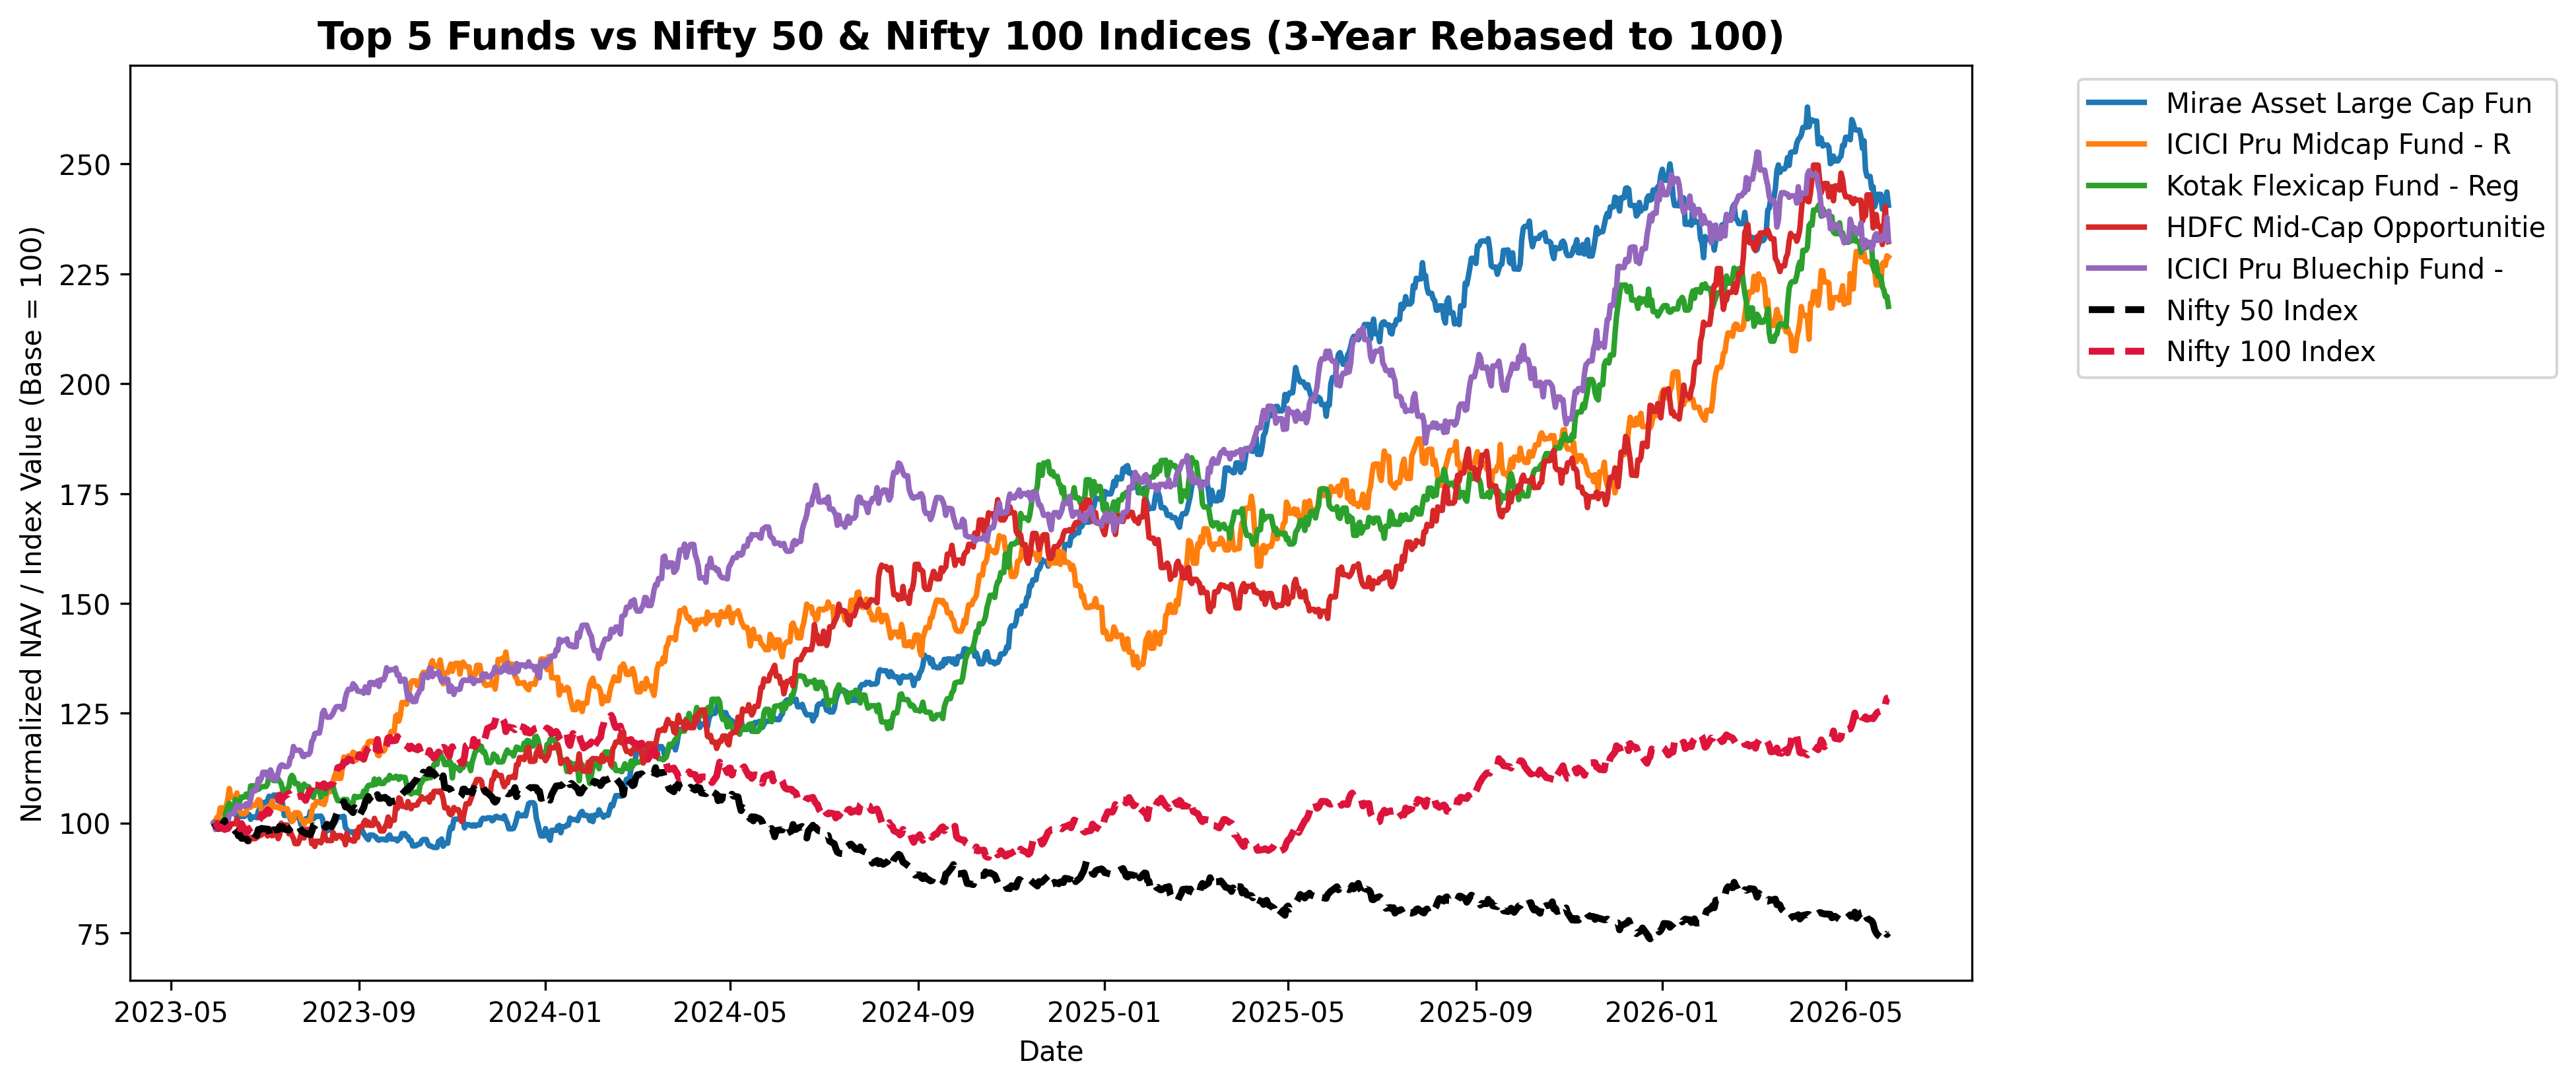

In [9]:
chart_path = Path('../figures/benchmark_chart.png') if Path('../figures/benchmark_chart.png').exists() else Path('figures/benchmark_chart.png')
from IPython.display import Image
display(Image(filename=str(chart_path)))

## 10. Summary & Phase 4 Deliverable Check
- All 8 tasks executed successfully.
- Generated deliverables: `returns_computed.csv`, `cagr_report.csv`, `sharpe_values.csv`, `sortino_values.csv`, `alpha_beta.csv`, `max_drawdown.csv`, `fund_scorecard.csv`, and `figures/benchmark_chart.png`.